In [46]:
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [2]:
transform = transforms.Compose([transforms.ToTensor(),transforms.Normalize(0.5,0.5)])
train_data = datasets.MNIST(root='data',download=True,train=True,transform=transform)
test_data = datasets.MNIST(root='data',download=True,train=False,transform=transform)
train_data,test_data

(Dataset MNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: Compose(
                ToTensor()
                Normalize(mean=0.5, std=0.5)
            ),
 Dataset MNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: Compose(
                ToTensor()
                Normalize(mean=0.5, std=0.5)
            ))

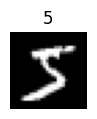

In [3]:
image,label = train_data[0]
def show_images(image,label):
    plt.figure(figsize=(1,1))
    plt.imshow(image.squeeze(),cmap="gray")
    plt.axis("off")
    plt.title(label)
    plt.show()

show_images(image,label)

In [4]:
torch.randint(len(train_data),(1,)).item()

9428

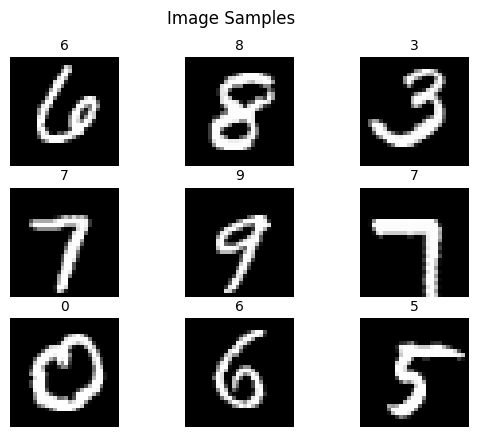

In [5]:
rows,cols = 3,3
figure,axes = plt.subplots(rows,cols)
figure.suptitle("Image Samples",fontsize=12)
axes = axes.flatten()


for ax in axes:
    idx = torch.randint(len(train_data),(1,)).item()
    image,label = train_data[idx]
    ax.imshow(image.squeeze(),cmap='gray')
    ax.axis("off")
    ax.set_title(label,fontsize=10)
plt.show()

In [6]:
train_loader = DataLoader(train_data,batch_size=64,shuffle=True)
test_loader = DataLoader(test_data,batch_size=64,shuffle=True)

In [7]:
images,labels = next(iter(train_loader))
images[0].shape

torch.Size([1, 28, 28])

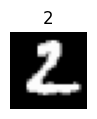

In [8]:
show_images(images[0],labels[0].item())

### Training Fully Connected Neural Network

In [9]:
class DigitClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,10)
        )
    def forward(self,x):
        return self.network(x)

In [10]:
model = DigitClassifier()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

In [11]:
total_batch = 0
for images,labels in train_loader:
    total_batch += 1
total_batch

938

In [12]:
epochs = 5
for epoch in range(epochs):
    running_loss = 0.0
    for images,labels in train_loader:
        predictions = model(images)
        loss = criterion(predictions,labels)
        running_loss += loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"Epoch: {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.3f}")
    

Epoch: 1/5, Loss: 0.403
Epoch: 2/5, Loss: 0.198
Epoch: 3/5, Loss: 0.140
Epoch: 4/5, Loss: 0.115
Epoch: 5/5, Loss: 0.096


In [37]:
# accuracy
model.eval()
all_labels = []
predicted_lables = []
total_predictions = 0
correct_predictions = 0

with torch.no_grad():
    for images,lables in test_loader:
        predictions = model(images)
        _,outputs = torch.max(predictions,1)
        # print(lables)
        all_labels.extend(lables)
        predicted_lables.extend(outputs)
        total_predictions += len(lables)
        correct_predictions += (outputs==lables).sum().item()
print(f"Accuracy -> {correct_predictions/total_predictions*100}%")

Accuracy -> 96.75%


In [42]:
report = classification_report(all_labels,predicted_lables)
print(report)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       980
           1       0.97      0.99      0.98      1135
           2       0.98      0.96      0.97      1032
           3       0.98      0.95      0.97      1010
           4       0.96      0.98      0.97       982
           5       0.97      0.96      0.96       892
           6       0.93      0.99      0.96       958
           7       0.98      0.94      0.96      1028
           8       0.96      0.97      0.96       974
           9       0.96      0.96      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [45]:
cm = confusion_matrix(all_labels,predicted_lables)
print(cm)

[[ 959    0    0    0    1    2   15    1    1    1]
 [   0 1122    1    1    0    1    6    0    4    0]
 [   6    3  992    1    5    0   11    7    7    0]
 [   0    0    7  961    0   17    1    5   14    5]
 [   1    0    1    0  958    0   11    1    0   10]
 [   5    2    0    4    2  853   15    1    6    4]
 [   2    3    0    0    3    2  947    0    1    0]
 [   1   18   10    2    4    0    1  970    4   18]
 [   2    0    0    2    4    5   12    4  942    3]
 [   3    5    0    5   17    2    1    1    4  971]]


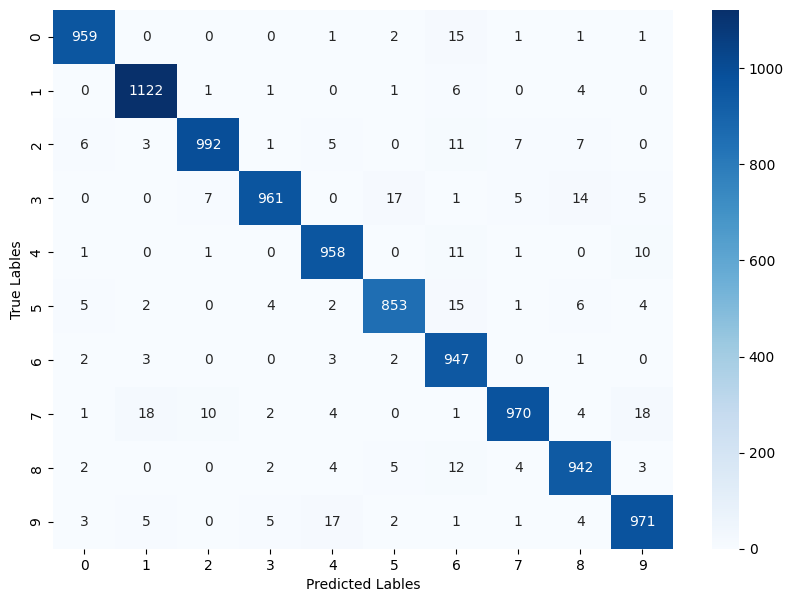

In [54]:
plt.figure(figsize=(10,7))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")
plt.ylabel("True Lables")
plt.xlabel("Predicted Lables")
plt.show()